# Orbit Correction Tests And Visual Walkthrough

This notebook runs the real MAD-X/cpymad correction workflow. The only dummy data are the three BPM readings in each plane.

Workflow:

1. Build the normal `MachineState` and load the ISIS closed-orbit-kick lattice.
2. Use three dummy BPM readings to fit a viable measured orbit with non-steering dipole kick knobs.
3. Treat the fitted TWISS orbit as the measured orbit.
4. Run MAD-X `CORRECT` with selected HD/VD steering dipoles.
5. Convert the proposed MAD-X steering kicks to currents using the ISIS per-corrector calibrations.
6. Plot measured orbit, corrected orbit, seed BPM points, and proposed currents.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import orbit_correction as oc
from cycle_time import RCSRamp
from machine_state import MachineState

pd.set_option("display.precision", 6)
plt.rcParams["figure.figsize"] = (11, 4)

## Machine State And Dummy BPM Measurements

The BPM values below are dummy readings in mm. They are not used as a synthetic orbit curve. MAD-X fits a closed orbit through these points first, then MAD-X `CORRECT` calculates steering corrections for that fitted orbit.

In [2]:
lattice_folder = Path("../Lattice_Files/03_CO_Kick_Lattice")
output_dir = Path("orbit_correction_tests/madx_correct")

beam_state = RCSRamp().state_at(0.0)
machine_state = MachineState.from_defaults(
    beam_state=beam_state,
    tune_method="di_wright",
)

h_bpm = oc.normalise_bpm_measurements([
    {"bpm": "R0HM1", "plane": "H", "closed_orbit_mm": 3.0, "closed_orbit_mm_err": 0.1},
    {"bpm": "R5HM1", "plane": "H", "closed_orbit_mm": -2.0, "closed_orbit_mm_err": 0.1},
    {"bpm": "R9HM1", "plane": "H", "closed_orbit_mm": 1.5, "closed_orbit_mm_err": 0.1},
])

v_bpm = oc.normalise_bpm_measurements([
    {"bpm": "R0VM1", "plane": "V", "closed_orbit_mm": -2.5, "closed_orbit_mm_err": 0.1},
    {"bpm": "R5VM1", "plane": "V", "closed_orbit_mm": 1.0, "closed_orbit_mm_err": 0.1},
    {"bpm": "R9VM2", "plane": "V", "closed_orbit_mm": 2.0, "closed_orbit_mm_err": 0.1},
])

display(pd.concat([h_bpm, v_bpm], ignore_index=True))

,bpm,plane,closed_orbit_mm,closed_orbit_mm_err,s,enabled
0,R0HM1,H,3.0,0.1,NaN,True
1,R5HM1,H,-2.0,0.1,NaN,True
2,R9HM1,H,1.5,0.1,NaN,True
3,R0VM1,V,-2.5,0.1,NaN,True
4,R5VM1,V,1.0,0.1,NaN,True
5,R9VM2,V,2.0,0.1,NaN,True


## BPM And Corrector Selection

This mirrors the COCU-style selection behaviour: individual BPMs and individual steering correctors can be enabled or disabled. Here the seed has three enabled BPMs per plane, and one steering corrector is disabled in each plane to prove the mask is honoured.

In [3]:
h_correctors = oc.set_corrector_enabled(
    oc.default_corrector_selection("H"),
    ["r9hd1_kick"],
    False,
)
v_correctors = oc.set_corrector_enabled(
    oc.default_corrector_selection("V"),
    ["r9vd1_kick"],
    False,
)

selection_table = pd.concat([h_correctors, v_correctors], ignore_index=True)
display(selection_table[["corrector", "plane", "superperiod", "enabled"]])

,corrector,plane,superperiod,enabled
0,r0hd1_kick,H,0,True
1,r2hd1_kick,H,2,True
2,r3hd1_kick,H,3,True
3,r4hd1_kick,H,4,True
4,r5hd1_kick,H,5,True
5,r7hd1_kick,H,7,True
6,r9hd1_kick,H,9,False
7,r0vd1_kick,V,0,True
8,r2vd1_kick,V,2,True
9,r3vd1_kick,V,3,True


## Run The Real MAD-X Workflow

`correct_bpm_measurements_with_madx_correct(...)` performs both MAD-X stages:

- `MATCH`: fit the three dummy BPM values using non-steering dipole kick knobs (`R0DIP_HKICK`, etc.). This creates the viable measured orbit.
- `CORRECT`: select the operational steering dipoles with `USEKICK`, select plane BPM monitors with `USEMONITOR`, then run MAD-X `CORRECT` against the ideal reference table.

In [4]:
h_result = oc.correct_bpm_measurements_with_madx_correct(
    plane="H",
    lattice_folder=lattice_folder,
    bpm_measurements=h_bpm,
    machine_state=machine_state,
    correctors=h_correctors,
    output_dir=output_dir,
)

v_result = oc.correct_bpm_measurements_with_madx_correct(
    plane="V",
    lattice_folder=lattice_folder,
    bpm_measurements=v_bpm,
    machine_state=machine_state,
    correctors=v_correctors,
    output_dir=output_dir,
)

pd.DataFrame([h_result.summary, v_result.summary])

,plane,read_only,workflow,n_seed_bpm,n_seed_fit_knobs,n_enabled_correctors,before,after,rms_change_mm
0,H,True,bpm_match_then_madx_correct,3,10,6,"{'n_monitor': 16, 'rms_orbit_mm': 2.5076193831...","{'n_monitor': 16, 'rms_orbit_mm': 1.0347944352...",-1.472825
1,V,True,bpm_match_then_madx_correct,3,10,6,"{'n_monitor': 20, 'rms_orbit_mm': 1.2641232807...","{'n_monitor': 20, 'rms_orbit_mm': 0.7692356640...",-0.494888


## Check The Seed Orbit Match

These residuals show whether the first MAD-X stage produced a viable measured orbit passing through the three dummy BPM values. The model values come from the matched TWISS table, not from a synthetic curve.

In [5]:
def with_bpm_positions(bpm_df, twiss_df):
    rows = []
    for _, row in bpm_df.iterrows():
        resolved = oc.resolve_bpm_to_twiss_name(row["bpm"], twiss_df, row["s"])
        out = dict(row)
        if resolved is not None:
            mask = twiss_df["name"].astype(str).str.lower().str.split(":").str[0] == resolved.lower()
            if mask.any():
                out["s"] = float(twiss_df.loc[mask].iloc[0]["s"])
        rows.append(out)
    return oc.normalise_bpm_measurements(rows)

h_bpm_plot = with_bpm_positions(h_result.bpm_measurements, h_result.reference_twiss_df)
v_bpm_plot = with_bpm_positions(v_result.bpm_measurements, v_result.reference_twiss_df)

h_seed_residuals = oc.orbit_residuals(h_result.measured_twiss_df, h_bpm_plot, "H")
v_seed_residuals = oc.orbit_residuals(v_result.measured_twiss_df, v_bpm_plot, "V")

display(h_seed_residuals[["bpm", "measurement_mm", "model_mm", "residual_mm"]])
display(v_seed_residuals[["bpm", "measurement_mm", "model_mm", "residual_mm"]])

,bpm,measurement_mm,model_mm,residual_mm
0,R0HM1,3.0,2.998559,-0.001441
1,R5HM1,-2.0,-2.000244,-0.000244
2,R9HM1,1.5,1.498334,-0.001666


,bpm,measurement_mm,model_mm,residual_mm
0,R0VM1,-2.5,-2.5,8.333176e-09
1,R5VM1,1.0,1.0,8.964935e-08
2,R9VM2,2.0,2.0,-8.428033e-08


## Measured Orbit And Corrected Orbit

The orange curve is the viable measured orbit created by MAD-X matching from the three dummy BPM readings. The green curve is the post-`CORRECT` MAD-X TWISS orbit using the selected steering dipoles.

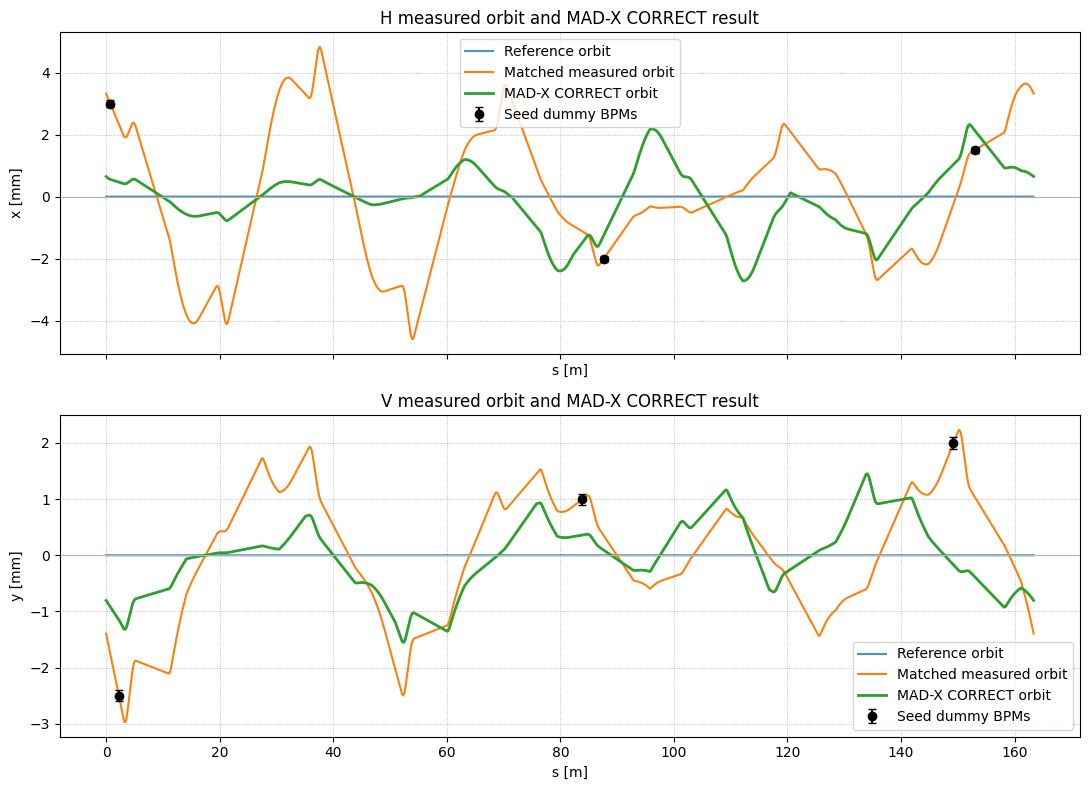

In [6]:
def plot_correct_workflow(result, bpm_plot, plane, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 4))
    coord = oc.plane_coordinate(plane)
    ax.plot(
        result.reference_twiss_df["s"],
        1e3 * result.reference_twiss_df[coord],
        label="Reference orbit",
        color="tab:blue",
        alpha=0.8,
    )
    ax.plot(
        result.measured_twiss_df["s"],
        1e3 * result.measured_twiss_df[coord],
        label="Matched measured orbit",
        color="tab:orange",
    )
    ax.plot(
        result.corrected_twiss_df["s"],
        1e3 * result.corrected_twiss_df[coord],
        label="MAD-X CORRECT orbit",
        color="tab:green",
        linewidth=2.0,
    )
    ax.errorbar(
        bpm_plot["s"],
        bpm_plot["closed_orbit_mm"],
        yerr=bpm_plot["closed_orbit_mm_err"],
        fmt="o",
        color="black",
        capsize=3,
        linestyle="none",
        label="Seed dummy BPMs",
    )
    ax.axhline(0.0, color="0.7", linewidth=0.8)
    ax.set_xlabel("s [m]")
    ax.set_ylabel(f"{coord} [mm]")
    ax.set_title(f"{plane} measured orbit and MAD-X CORRECT result")
    ax.grid(True, linestyle=":", linewidth=0.6)
    ax.legend(loc="best")
    return ax

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
plot_correct_workflow(h_result, h_bpm_plot, "H", ax=axes[0])
plot_correct_workflow(v_result, v_bpm_plot, "V", ax=axes[1])
fig.tight_layout()

## Full Monitor RMS Before And After CORRECT

This uses all H or V BPM monitor elements selected by MAD-X `USEMONITOR`, not just the three seed points.

In [7]:
summary_rows = []
for result in (h_result, v_result):
    summary_rows.append({
        "plane": result.plane,
        "n_monitors": result.monitor_summary_before["n_monitor"],
        "measured_rms_mm": result.monitor_summary_before["rms_orbit_mm"],
        "corrected_rms_mm": result.monitor_summary_after["rms_orbit_mm"],
        "rms_change_mm": result.summary["rms_change_mm"],
        "measured_max_abs_mm": result.monitor_summary_before["max_abs_orbit_mm"],
        "corrected_max_abs_mm": result.monitor_summary_after["max_abs_orbit_mm"],
    })

monitor_summary = pd.DataFrame(summary_rows)
display(monitor_summary)

,plane,n_monitors,measured_rms_mm,corrected_rms_mm,rms_change_mm,measured_max_abs_mm,corrected_max_abs_mm
0,H,16,2.507619,1.034794,-1.472825,4.086946,2.131628
1,V,20,1.264123,0.769236,-0.494888,2.500000,1.340622


## Corrector Kicks And Currents

The kicks come from the MAD-X `CORRECT` `clist` table (`PX.CORRECTION` or `PY.CORRECTION`). The currents are converted with the per-superperiod ISIS steering calibrations in `correctors.py`, matching the values from the `isis_2024` helper functions.

In [8]:
h_currents = h_result.correctors[[
    "corrector", "enabled", "delta_kick_mrad", "delta_current_A"
]].copy()
v_currents = v_result.correctors[[
    "corrector", "enabled", "delta_kick_mrad", "delta_current_A"
]].copy()

display(h_currents)
display(v_currents)

,corrector,enabled,delta_kick_mrad,delta_current_A
0,r0hd1_kick,True,0.094179,1.388769
1,r2hd1_kick,True,0.009248,0.124840
2,r3hd1_kick,True,0.079650,1.225898
3,r4hd1_kick,True,-0.076795,-1.432684
4,r5hd1_kick,True,-0.110245,-1.744779
5,r7hd1_kick,True,-0.410329,-6.665364
6,r9hd1_kick,False,0.000000,0.000000


,corrector,enabled,delta_kick_mrad,delta_current_A
0,r0vd1_kick,True,-0.037848,-1.008708
1,r2vd1_kick,True,-0.100686,-2.863134
2,r3vd1_kick,True,-0.093284,-2.204594
3,r4vd1_kick,True,-0.117888,-3.043079
4,r5vd1_kick,True,0.000000,0.000000
5,r7vd1_kick,True,0.203090,4.790474
6,r9vd1_kick,False,0.000000,0.000000


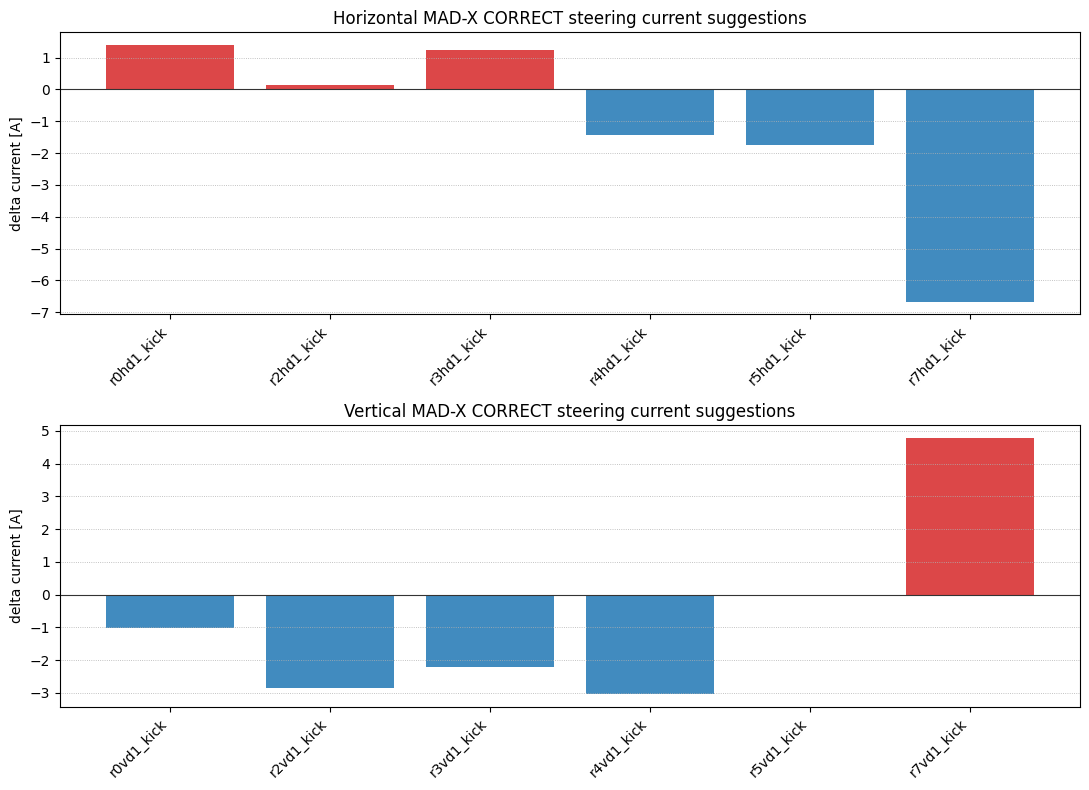

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)
oc.plot_corrector_suggestions(
    h_result.correctors,
    ax=axes[0],
    value="delta_current_A",
    title="Horizontal MAD-X CORRECT steering current suggestions",
)
oc.plot_corrector_suggestions(
    v_result.correctors,
    ax=axes[1],
    value="delta_current_A",
    title="Vertical MAD-X CORRECT steering current suggestions",
)
fig.tight_layout()

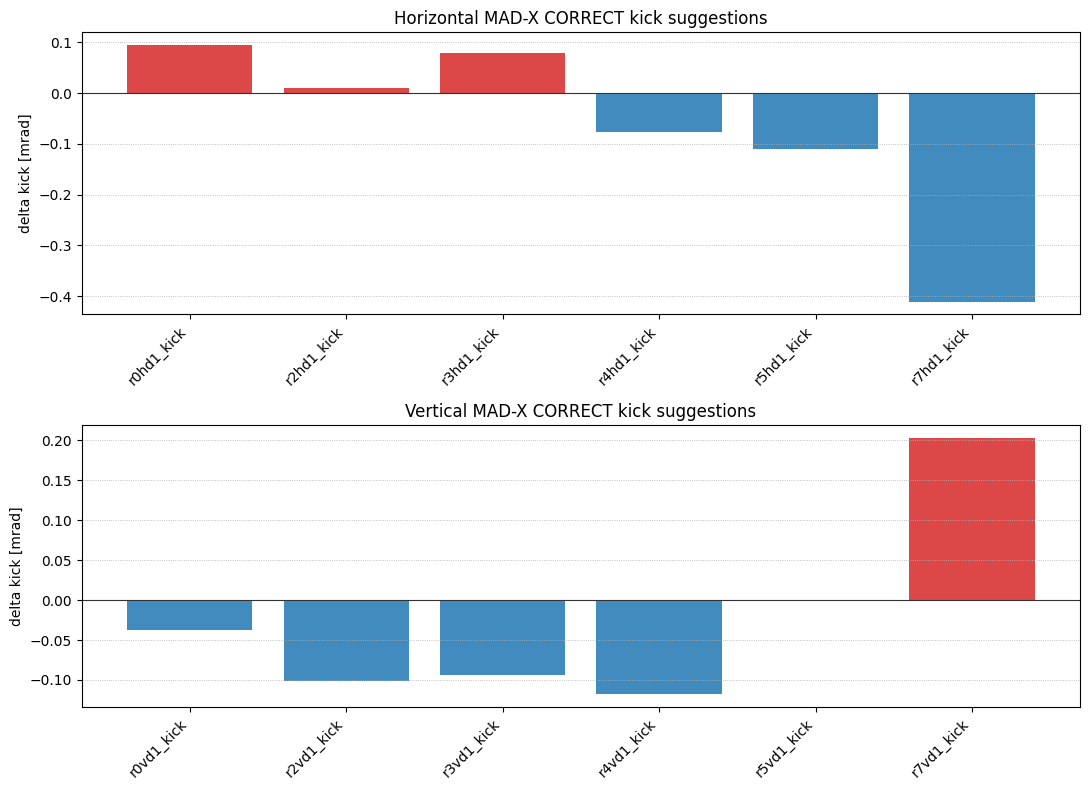

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)
oc.plot_corrector_suggestions(
    h_result.correctors,
    ax=axes[0],
    value="delta_kick_mrad",
    title="Horizontal MAD-X CORRECT kick suggestions",
)
oc.plot_corrector_suggestions(
    v_result.correctors,
    ax=axes[1],
    value="delta_kick_mrad",
    title="Vertical MAD-X CORRECT kick suggestions",
)
fig.tight_layout()

## Validation Assertions

The final cell is deliberately executed. It checks that cpymad/MAD-X ran, the seed fit hit the dummy BPM readings, disabled correctors stayed at zero, and MAD-X `CORRECT` reduced the full monitor RMS in each plane.

In [11]:
assert h_result.summary["after"]["rms_orbit_mm"] < h_result.summary["before"]["rms_orbit_mm"]
assert v_result.summary["after"]["rms_orbit_mm"] < v_result.summary["before"]["rms_orbit_mm"]
assert h_seed_residuals["residual_mm"].abs().max() < 0.02
assert v_seed_residuals["residual_mm"].abs().max() < 0.02
assert h_result.correctors.loc[h_result.correctors["corrector"] == "r9hd1_kick", "delta_kick_rad"].iloc[0] == 0.0
assert v_result.correctors.loc[v_result.correctors["corrector"] == "r9vd1_kick", "delta_kick_rad"].iloc[0] == 0.0
assert np.isfinite(h_result.correctors.loc[h_result.correctors["enabled"], "delta_current_A"]).all()
assert np.isfinite(v_result.correctors.loc[v_result.correctors["enabled"], "delta_current_A"]).all()

print("MAD-X orbit correction notebook checks passed")

MAD-X orbit correction notebook checks passed
